<a href="https://colab.research.google.com/github/idabelZone/Proyecto-DA-AluraStoreLatam/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [7]:
# 1. Para calcular la suma de la columna 'Precio' para cada DataFrame
ingreso_t1 = tienda['Precio'].sum()
ingreso_t2 = tienda2['Precio'].sum()
ingreso_t3 = tienda3['Precio'].sum()
ingreso_t4 = tienda4['Precio'].sum()

# 2. Para mostramos los resultados de forma legible
print("REPORTE DE FACTURACIÓN TOTAL")
print(f"Tienda 1: ${ingreso_t1:,.2f}")
print(f"Tienda 2: ${ingreso_t2:,.2f}")
print(f"Tienda 3: ${ingreso_t3:,.2f}")
print(f"Tienda 4: ${ingreso_t4:,.2f}")


resumen_ingresos = {
    "Tienda 1": ingreso_t1,
    "Tienda 2": ingreso_t2,
    "Tienda 3": ingreso_t3,
    "Tienda 4": ingreso_t4
}

REPORTE DE FACTURACIÓN TOTAL
Tienda 1: $1,150,880,400.00
Tienda 2: $1,116,343,500.00
Tienda 3: $1,098,019,600.00
Tienda 4: $1,038,375,700.00


In [5]:
# Paso extra para que sea más práctico el resultado e identificar la tienda con menor ingreso automáticamente
peor_tienda = min(resumen_ingresos, key=resumen_ingresos.get)
print(f"\nNota para el Sr. Juan: La tienda con menor facturación actual es: {peor_tienda}")


Nota para el Sr. Juan: La tienda con menor facturación actual es: Tienda 4


# 2. Ventas por categoría

In [15]:

# Para el análisis de la Tienda 1
print("Popularidad por Categoría: Tienda 1")
print(tienda['Categoría del Producto'].value_counts().to_frame())

# Para el análisis de la Tienda 2
print("\nPopularidad por Categoría: Tienda 2")
print(tienda2['Categoría del Producto'].value_counts().to_frame())

# Para el análisis de la Tienda 3
print("\nPopularidad por Categoría: Tienda 3")
print(tienda3['Categoría del Producto'].value_counts().to_frame())

# Para el análisis de la Tienda 4
print("\nPopularidad por Categoría: Tienda 4")
print(tienda4['Categoría del Producto'].value_counts().to_frame())

Popularidad por Categoría: Tienda 1
                         count
Categoría del Producto        
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171

Popularidad por Categoría: Tienda 2
                         count
Categoría del Producto        
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181

Popularidad por Categoría: Tienda 3
                         count
Categoría del Producto        
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales

In [16]:
# --- EXTRA STEP: Resumen Consolidado de Popularidad ---

# Crear un solo DataFrame que una todos los conteos
resumen_categorias = pd.DataFrame({
    'Tienda 1': tienda['Categoría del Producto'].value_counts(),
    'Tienda 2': tienda2['Categoría del Producto'].value_counts(),
    'Tienda 3': tienda3['Categoría del Producto'].value_counts(),
    'Tienda 4': tienda4['Categoría del Producto'].value_counts()
})

# 2. Mostrar la tabla comparativa completa
print("TABLA COMPARATIVA DE VENTAS POR CATEGORÍA")
display(resumen_categorias)

# 3. Un resumen de Ganadores (La categoría más popular de cada una)
print("\nLÍDERES POR TIENDA")
for columna in resumen_categorias.columns:
    categoria_top = resumen_categorias[columna].idxmax()
    ventas_top = resumen_categorias[columna].max()
    print(f"En la {columna}, la categoría reina es '{categoria_top}' con {ventas_top} ventas.")

TABLA COMPARATIVA DE VENTAS POR CATEGORÍA


,Tienda 1,Tienda 2,Tienda 3,Tienda 4
Categoría del Producto,,,,
Artículos para el hogar,171,181,177,201
Deportes y diversión,284,275,277,277
Electrodomésticos,312,305,278,254
Electrónicos,448,422,451,451
Instrumentos musicales,182,224,177,170
Juguetes,324,313,315,338
Libros,173,197,185,187
Muebles,465,442,499,480



LÍDERES POR TIENDA
En la Tienda 1, la categoría reina es 'Muebles' con 465 ventas.
En la Tienda 2, la categoría reina es 'Muebles' con 442 ventas.
En la Tienda 3, la categoría reina es 'Muebles' con 499 ventas.
En la Tienda 4, la categoría reina es 'Muebles' con 480 ventas.


# 3. Calificación promedio de la tienda


In [33]:

# Para calcular el promedio para cada tienda
prom_t1 = tienda['Calificación'].mean()
prom_t2 = tienda2['Calificación'].mean()
prom_t3 = tienda3['Calificación'].mean()
prom_t4 = tienda4['Calificación'].mean()

print("SATISFACCIÓN DEL CLIENTE (1 a 5)")
print(f"Tienda 1: {prom_t1:.2f}")
print(f"Tienda 2: {prom_t2:.2f}")
print(f"Tienda 3: {prom_t3:.2f}")
print(f"Tienda 4: {prom_t4:.2f}")



SATISFACCIÓN DEL CLIENTE (1 a 5)
Tienda 1: 3.98
Tienda 2: 4.04
Tienda 3: 4.05
Tienda 4: 4.00


In [32]:
# Paso extra: para identificar la tienda con clientes más insatisfechos
promedios = {
    "Tienda 1": prom_t1,
    "Tienda 2": prom_t2,
    "Tienda 3": prom_t3,
    "Tienda 4": prom_t4
}

peor_rating = min(promedios, key=promedios.get)
print(f"\n Alerta para el Sr. Juan: La {peor_rating} tiene la calificación más baja.")


 Alerta para el Sr. Juan: La Tienda 1 tiene la calificación más baja.


# 4. Productos más y menos vendidos

In [25]:
# Se crea una función para extraer los extremos de ventas
def obtener_extremos(df, nombre_tienda):
    conteo_productos = df['Producto'].value_counts()

    mas_vendido = conteo_productos.idxmax()
    cantidad_mas = conteo_productos.max()

    menos_vendido = conteo_productos.idxmin()
    cantidad_menos = conteo_productos.min()

    return {
        "Tienda": nombre_tienda,
        "Producto Más Vendido": mas_vendido,
        "Ventas (Máx)": cantidad_mas,
        "Producto Menos Vendido": menos_vendido,
        "Ventas (Mín)": cantidad_menos
    }

# Se ejecuta el análisis y se guarda en una lista
analisis_productos = []
analisis_productos.append(obtener_extremos(tienda, "Tienda 1"))
analisis_productos.append(obtener_extremos(tienda2, "Tienda 2"))
analisis_productos.append(obtener_extremos(tienda3, "Tienda 3"))
analisis_productos.append(obtener_extremos(tienda4, "Tienda 4"))

# Para convertir a DataFrame para que el Sr. Juan lo vea como una tabla limpia
df_reporte_productos = pd.DataFrame(analisis_productos)

# Mostramos el resultado
print("REPORTE TÉCNICO DE PRODUCTOS")
display(df_reporte_productos)

REPORTE TÉCNICO DE PRODUCTOS


,Tienda,Producto Más Vendido,Ventas (Máx),Producto Menos Vendido,Ventas (Mín)
0,Tienda 1,Microondas,60,Auriculares con micrófono,33
1,Tienda 2,Iniciando en programación,65,Juego de mesa,32
2,Tienda 3,Kit de bancas,57,Bloques de construcción,35
3,Tienda 4,Cama box,62,Guitarra eléctrica,33


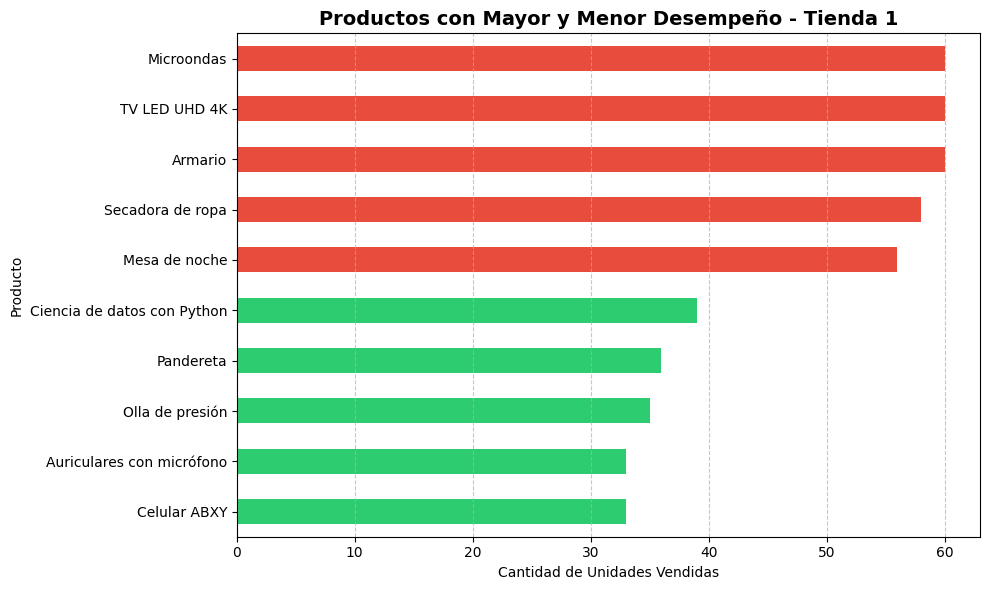

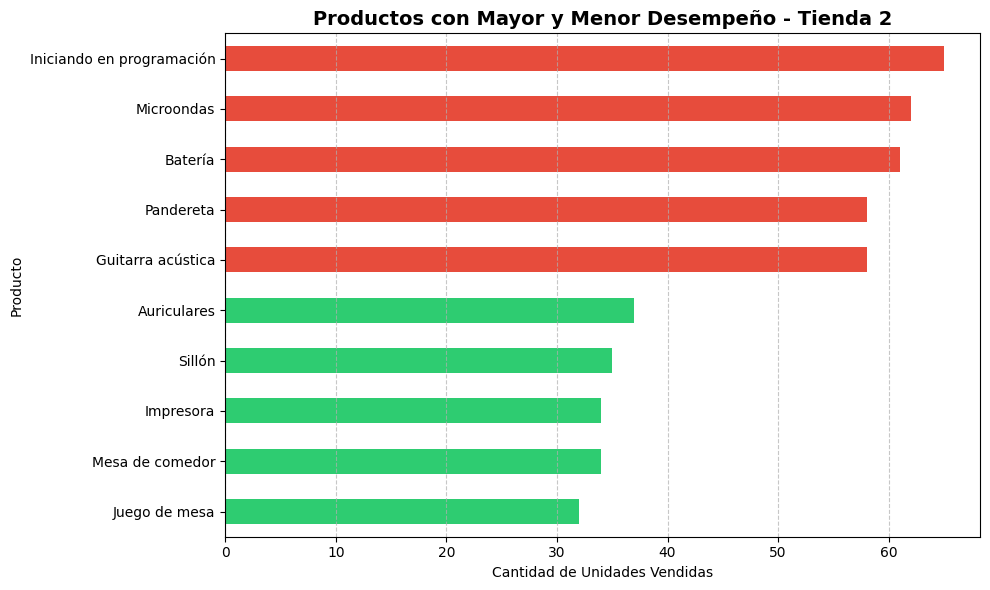

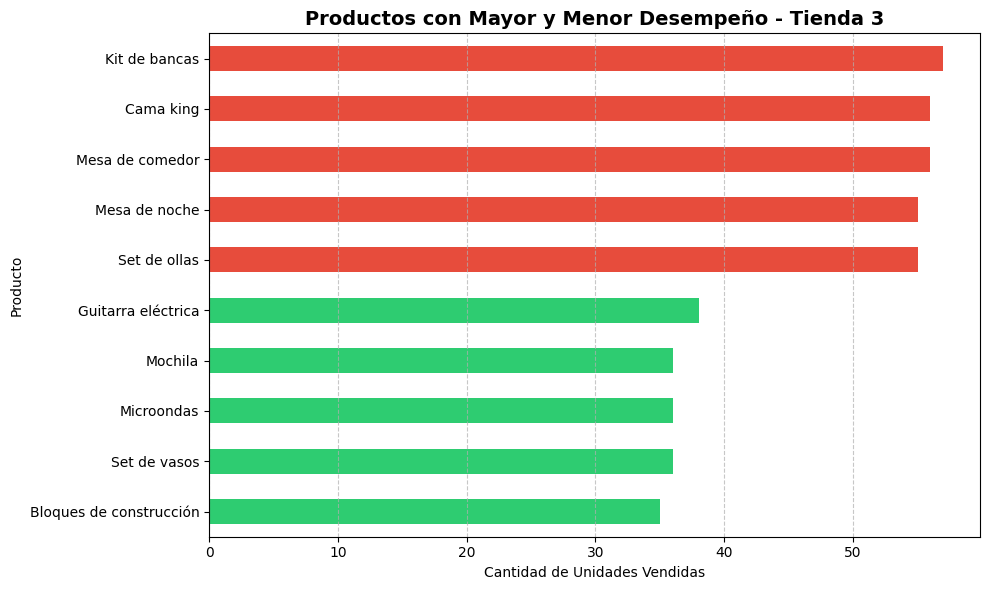

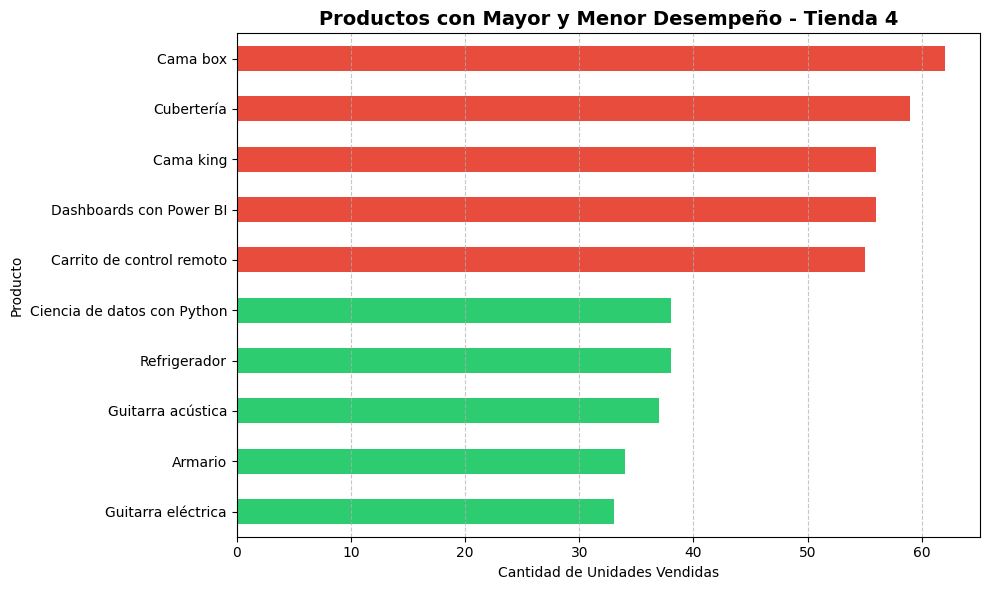

In [26]:
#VISUALIZACIÓN (Gráficos de Productos Destacados)

import matplotlib.pyplot as plt

# Se define una lista con los DataFrames
lista_tiendas = [(tienda, "Tienda 1"), (tienda2, "Tienda 2"),
                 (tienda3, "Tienda 3"), (tienda4, "Tienda 4")]

# Se crean los gráficos
for df, nombre in lista_tiendas:
    # Se cuentan los productos y tomamos los 5 mejores y 5 peores
    conteo = df['Producto'].value_counts()
    top_5 = conteo.head(5)
    bottom_5 = conteo.tail(5)

    # Se unen ambos para el gráfico
    resultado_visual = pd.concat([top_5, bottom_5])

    # Configuración del diseño del gráfico
    plt.figure(figsize=(10, 6))
    colores = ['#2ecc71'] * 5 + ['#e74c3c'] * 5  # Verde para top, Rojo para bottom

    resultado_visual.sort_values().plot(kind='barh', color=colores)

    #  Las etiquetas y títulos
    plt.title(f"Productos con Mayor y Menor Desempeño - {nombre}", fontsize=14, fontweight='bold')
    plt.xlabel("Cantidad de Unidades Vendidas")
    plt.ylabel("Producto")
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    # Mostramos el gráfico
    plt.tight_layout()
    plt.show()

# 5. Envío promedio por tienda

In [31]:
# Se calcula el promedio de la columna 'Costo de envío' para cada tienda
envio_t1 = tienda['Costo de envío'].mean()
envio_t2 = tienda2['Costo de envío'].mean()
envio_t3 = tienda3['Costo de envío'].mean()
envio_t4 = tienda4['Costo de envío'].mean()

# Se crea un pequeño DataFrame para comparar los resultados de forma limpia
df_envios = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Costo Promedio Envío': [envio_t1, envio_t2, envio_t3, envio_t4]
})

print("--- REPORTE DE GASTOS LOGÍSTICOS PROMEDIO ---")
display(df_envios.style.format({'Costo Promedio Envío': '${:,.2f}'}))

# Paso para un insight
tienda_cara = df_envios.loc[df_envios['Costo Promedio Envío'].idxmax(), 'Tienda']
print(f"\n Nota estratégica: La {tienda_cara} tiene el envío más costoso en promedio.")

--- REPORTE DE GASTOS LOGÍSTICOS PROMEDIO ---


,Tienda,Costo Promedio Envío
0,Tienda 1,"$26,018.61"
1,Tienda 2,"$25,216.24"
2,Tienda 3,"$24,805.68"
3,Tienda 4,"$23,459.46"



 Nota estratégica: La Tienda 1 tiene el envío más costoso en promedio.


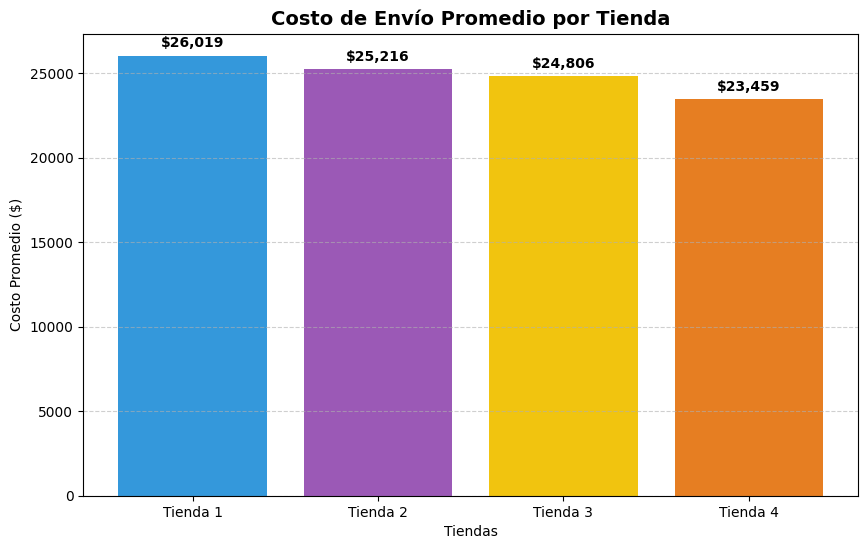

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Gráfico de barras
colores_envio = ['#3498db', '#9b59b6', '#f1c40f', '#e67e22'] # Un color diferente para cada tienda
plt.bar(df_envios['Tienda'], df_envios['Costo Promedio Envío'], color=colores_envio)

# Detalles para que sea fácil de leer
plt.title('Costo de Envío Promedio por Tienda', fontsize=14, fontweight='bold')
plt.ylabel('Costo Promedio ($)')
plt.xlabel('Tiendas')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Para añadir el valor exacto sobre cada barra
for i, v in enumerate(df_envios['Costo Promedio Envío']):
    plt.text(i, v + 500, f'${v:,.0f}', ha='center', fontweight='bold')

plt.show()

##Gráficos adicionales para un mejor análisis

***Gráfico de Dispersión: Precio vs. Calificación***

In [36]:
import pandas as pd

# Se crea una lista para guardar los resultados
analisis_corr = []

for df, nombre in [(tienda, "Tienda 1"), (tienda2, "Tienda 2"),
                   (tienda3, "Tienda 3"), (tienda4, "Tienda 4")]:

    # Se calcula la correlación (va de -1 a 1)
    correlacion = df['Precio'].corr(df['Calificación'])

    analisis_corr.append({
        "Tienda": nombre,
        "Correlación": round(correlacion, 4)
    })

df_corr = pd.DataFrame(analisis_corr)
print("RESULTADOS DEL ANÁLISIS")
display(df_corr)

print("\n Interpretación: Si el número es cercano a 0 (como en este caso), significa que")
print("el precio NO afecta la calificación. ¡Los clientes son igual de exigentes con lo barato y lo caro!")

RESULTADOS DEL ANÁLISIS


,Tienda,Correlación
0,Tienda 1,0.0206
1,Tienda 2,0.0085
2,Tienda 3,-0.0052
3,Tienda 4,-0.0197



 Interpretación: Si el número es cercano a 0 (como en este caso), significa que
el precio NO afecta la calificación. ¡Los clientes son igual de exigentes con lo barato y lo caro!


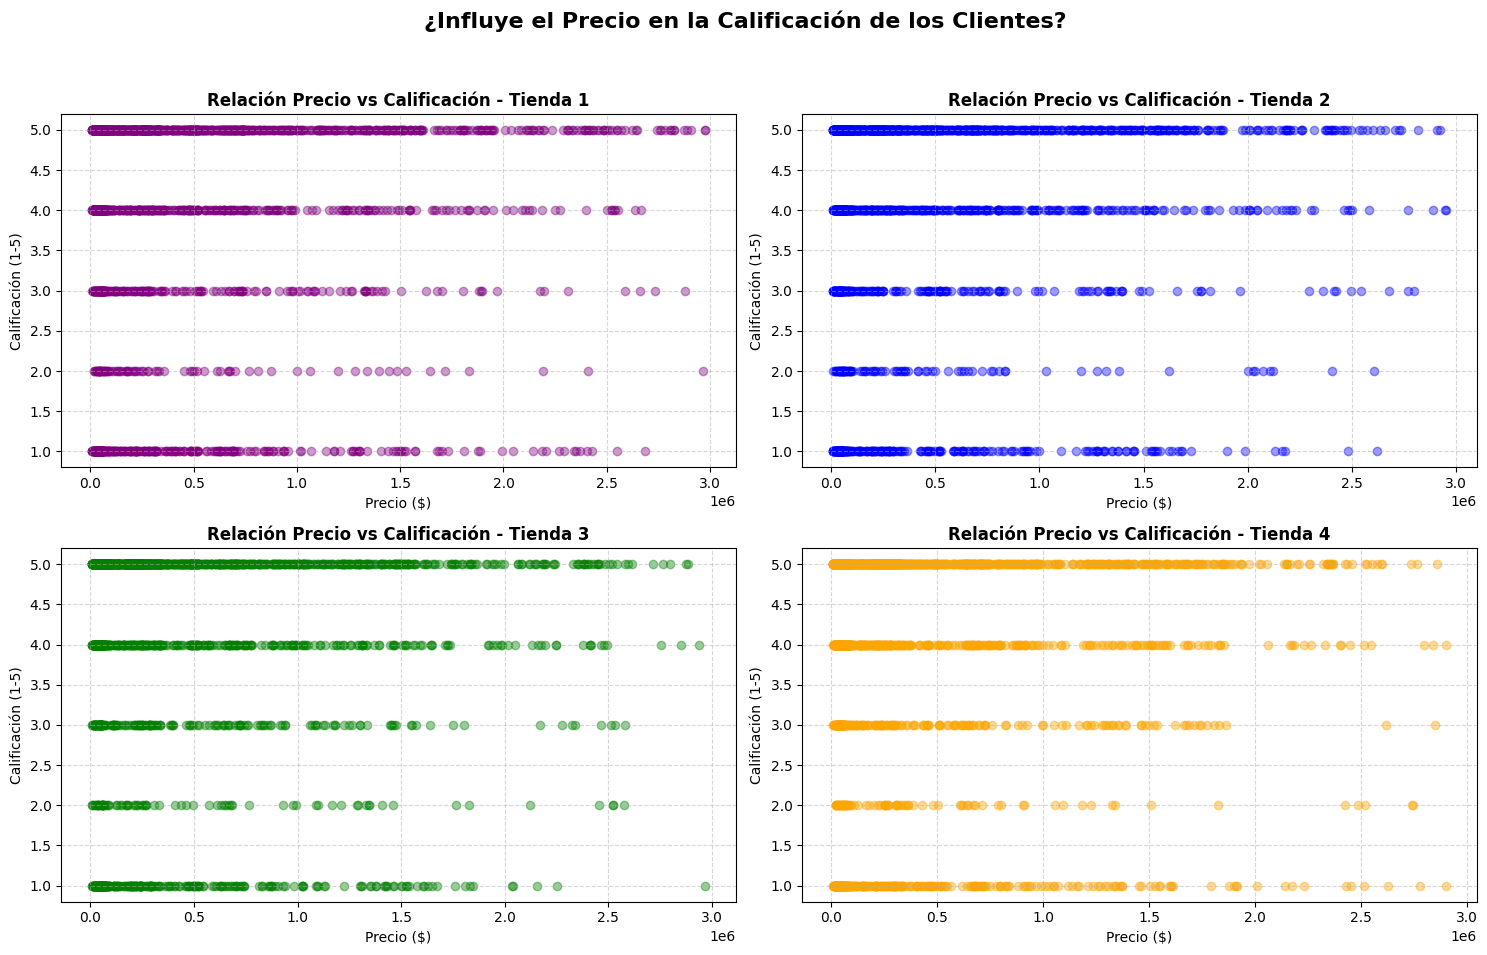

In [37]:
import matplotlib.pyplot as plt

# Se crea una cuadrícula de 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

lista_tiendas = [(tienda, "Tienda 1", "purple"), (tienda2, "Tienda 2", "blue"),
                 (tienda3, "Tienda 3", "green"), (tienda4, "Tienda 4", "orange")]

for i, (df, nombre, color) in enumerate(lista_tiendas):
    axes[i].scatter(df['Precio'], df['Calificación'], alpha=0.4, c=color)
    axes[i].set_title(f'Relación Precio vs Calificación - {nombre}', fontweight='bold')
    axes[i].set_xlabel('Precio ($)')
    axes[i].set_ylabel('Calificación (1-5)')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('¿Influye el Precio en la Calificación de los Clientes?', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

***Análisis de facturación, calificación, volumen, ventas y precio de envío***

In [38]:
def extraer_pilares(df):
    return {
        'Facturación': df['Precio'].sum(),
        'Calificación': df['Calificación'].mean(),
        'Ventas': len(df),
        'Ahorro Envío': 1 / df['Costo de envío'].mean()
    }

# Se extraen los datos de las 4 tiendas
datos_radar = [extraer_pilares(tienda), extraer_pilares(tienda2),
               extraer_pilares(tienda3), extraer_pilares(tienda4)]

df_radar = pd.DataFrame(datos_radar, index=['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'])

# Para que el radar sea equilibrado
df_norm = (df_radar - df_radar.min()) / (df_radar.max() - df_radar.min())

print("MÉTRICAS NORMALIZADAS PARA EL RADAR")
display(df_norm)

--- MÉTRICAS NORMALIZADAS PARA EL RADAR ---


,Facturación,Calificación,Ventas,Ahorro Envío
Tienda 1,1.000000,0.000000,1.0,0.000000
Tienda 2,0.693018,0.846154,1.0,0.291688
Tienda 3,0.530146,1.000000,1.0,0.448235
Tienda 4,0.000000,0.266247,0.0,1.000000


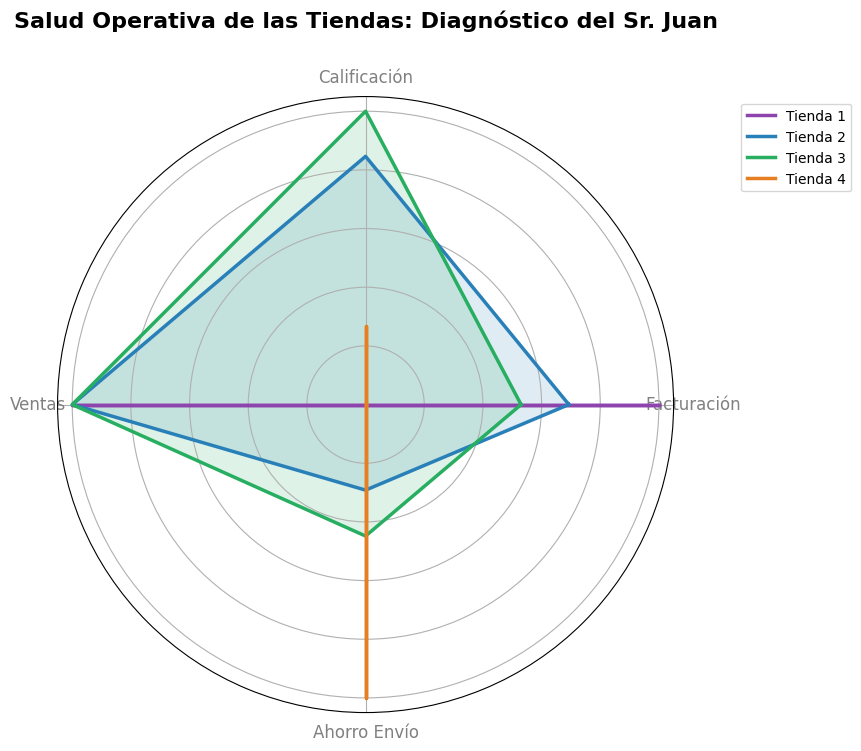

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Configuración básica
categorias = list(df_norm.columns)
N = len(categorias)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1] # Se cierra el círculo

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colores = ['#8e44ad', '#2980b9', '#27ae60', '#e67e22'] # Morado, Azul, Verde, Naranja

for i, tienda_nombre in enumerate(df_norm.index):
    valores = df_norm.loc[tienda_nombre].values.flatten().tolist()
    valores += valores[:1] # Se cierra el círculo

    # Para la línea y el relleno
    ax.plot(angulos, valores, linewidth=2.5, linestyle='solid', label=tienda_nombre, color=colores[i])
    ax.fill(angulos, valores, color=colores[i], alpha=0.15)

# Las etiquetas
plt.xticks(angulos[:-1], categorias, color='grey', size=12)
ax.set_yticklabels([]) # Se quitan los números internos para no perder el foco

plt.title('Salud Operativa de las Tiendas: Diagnóstico del Sr. Juan', size=16, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.show()

##Relatorio

Decirle al Sr. Juan cuál es la tienda que menos lucro está generando y que debería de vender (la tienda)

Analizar datos de la tienda:

Debes evaluar información como los ingresos, las categorías más vendidas, las reseñas de los clientes, los productos más vendidos y el envío promedio.



Crear gráficos para visualización:

Decide qué tipos de gráficos utilizar para presentar los resultados de forma clara y visual.

Mínimo de 3 gráficos diferentes, que pueden incluir gráficos de barras, circulares, de dispersión y otros.



Enviar una recomendación:

Después del análisis, escriba un texto explicando a qué tienda debería vender el Sr. João y por qué, basándose en los datos presentados.